# Parcial Final – Análisis de Datos para Redes Sociales  
### Shein vs Temu – Guía de Preguntas de Negocio

Este cuaderno está diseñado para acompañar el **parcial final**.  
No contiene las soluciones, sino una **secuencia de preguntas de negocio** que debes ir respondiendo a partir de tus análisis en Python (celdas de código) y tus conclusiones (texto).

> **Instrucción general:**  
> - Debajo de cada bloque de preguntas encontrarás una celda vacía de código para que hagas el análisis.  
> - Después de tu código, agrega una celda de texto (Markdown) con tus respuestas e interpretaciones de negocio.


In [1]:
!wget https://github.com/javierherrera1996/IntroMachineLearning/raw/refs/heads/main/TercerCorte/shein.csv

--2025-11-28 02:22:20--  https://github.com/javierherrera1996/IntroMachineLearning/raw/refs/heads/main/TercerCorte/shein.csv
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/javierherrera1996/IntroMachineLearning/refs/heads/main/TercerCorte/shein.csv [following]
--2025-11-28 02:22:21--  https://raw.githubusercontent.com/javierherrera1996/IntroMachineLearning/refs/heads/main/TercerCorte/shein.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1760315 (1.7M) [text/plain]
Saving to: ‘shein.csv’

shein.csv           100%[===================>]   1.68M  8.95MB/s    in 0.2s    

2025-11-28 02:22:21 (

In [2]:
!wget https://github.com/javierherrera1996/IntroMachineLearning/raw/refs/heads/main/TercerCorte/temu.csv

--2025-11-28 02:22:24--  https://github.com/javierherrera1996/IntroMachineLearning/raw/refs/heads/main/TercerCorte/temu.csv
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/javierherrera1996/IntroMachineLearning/refs/heads/main/TercerCorte/temu.csv [following]
--2025-11-28 02:22:24--  https://raw.githubusercontent.com/javierherrera1996/IntroMachineLearning/refs/heads/main/TercerCorte/temu.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 346171 (338K) [text/plain]
Saving to: ‘temu.csv’

temu.csv            100%[===================>] 338.06K  --.-KB/s    in 0.1s    

2025-11-28 02:22:25 (3.00 

## 2. Ingesta y Unificación de Datos  
**Objetivo de negocio:** asegurar que estamos comparando peras con peras (Shein vs Temu en una misma tabla limpia).

### 2.1. Preguntas de negocio

1. **Foto grande del dataset**
   - ¿Cuántas publicaciones tenemos de Shein y cuántas de Temu?  
   - ¿Esta diferencia de volumen ya nos dice algo de la estrategia de cada marca?

2. **Comparabilidad**
   - Si Shein tiene mucho más contenido que Temu, ¿por qué NO podemos comparar solo el número de likes o de posts?  
   - ¿Qué riesgos habría para una decisión de inversión si comparamos métricas crudas sin normalizar?

3. **Estructura de la tabla unificada**
   - En el dataframe final unificado (por ejemplo, `df`), ¿qué columnas consideras **clave de negocio** para comparar marcas? (ej: `brand`, `likes`, `comments`, `views`, `published_at`, etc.).  
   - Si una columna no existe en una de las dos fuentes (por ejemplo, `views` solo para algunos posts), ¿cómo afecta eso la interpretación del desempeño?

4. **Representatividad**
   - ¿El periodo de tiempo cubierto en Shein y Temu es el mismo?  
   - Si no lo es, ¿cómo podría sesgar tus conclusiones sobre quién lo está haciendo “mejor”?


In [3]:
import pandas as pd

dfshein = pd.read_csv("shein.csv")
dftemu = pd.read_csv("temu.csv")

In [4]:
dfshein.head()

,alt,audioUrl,caption,childPosts/0/alt,childPosts/0/caption,childPosts/0/commentsCount,childPosts/0/dimensionsHeight,childPosts/0/dimensionsWidth,childPosts/0/displayUrl,childPosts/0/firstComment,...,ownerUsername,productType,shortCode,timestamp,type,url,videoDuration,videoPlayCount,videoUrl,videoViewCount
0,"Photo by shein_co on November 25, 2025. May be...",NaN,¿De compras para encontrar las mejores ofertas...,"Photo by shein_co on November 25, 2025. May be...",NaN,0.0,1350.0,1080.0,https://scontent-atl3-2.cdninstagram.com/v/t51...,NaN,...,shein_colombia,NaN,DRetnrflmeB,2025-11-25T12:46:02.000Z,Sidecar,https://www.instagram.com/p/DRetnrflmeB/,NaN,NaN,NaN,NaN
1,"Photo by shein_co on September 26, 2025. May b...",NaN,Recién recogido y fabuloso—¿qué vestido es tu ...,"Photo by shein_co on September 26, 2025. May b...",NaN,0.0,1350.0,1080.0,https://scontent-hou1-1.cdninstagram.com/v/t51...,NaN,...,shein_colombia,NaN,DPEXbp5jtSe,2025-09-26T14:08:01.000Z,Sidecar,https://www.instagram.com/p/DPEXbp5jtSe/,NaN,NaN,NaN,NaN
2,"Photo by shein_co on October 03, 2025. May be ...",NaN,"Una energía de un solo tono, esa flexión codif...","Photo by shein_co on October 03, 2025. May be ...",NaN,0.0,1350.0,1080.0,https://scontent-ord5-2.cdninstagram.com/v/t51...,NaN,...,shein_colombia,NaN,DPWh7lTASw0,2025-10-03T15:26:01.000Z,Sidecar,https://www.instagram.com/p/DPWh7lTASw0/,NaN,NaN,NaN,NaN
3,"Photo by shein_co on November 26, 2025. May be...",NaN,"Todo lo que escuchamos fue ""quédate en casa"" y...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,shein_colombia,NaN,DRhbjBhgaUs,2025-11-26T14:06:02.000Z,Image,https://www.instagram.com/p/DRhbjBhgaUs/,NaN,NaN,NaN,NaN
4,"Photo by shein_co on September 19, 2025. May b...",NaN,La única necesidad que tengo para poder termin...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,shein_colombia,NaN,DOycs74DXgF,2025-09-19T15:08:01.000Z,Image,https://www.instagram.com/p/DOycs74DXgF/,NaN,NaN,NaN,NaN


In [5]:
dfshein.shape

(200, 633)

In [6]:
dftemu.head()

,alt,audioUrl,caption,commentsCount,dimensionsHeight,dimensionsWidth,displayUrl,firstComment,hashtags/0,hashtags/1,...,ownerUsername,productType,shortCode,timestamp,type,url,videoDuration,videoPlayCount,videoUrl,videoViewCount
0,"Photo by TemuColombia on July 11, 2025.",NaN,¡Alerta de promoción! Descubre productos que s...,15,1080,1080,https://scontent-lax7-1.cdninstagram.com/v/t51...,🤬🤬🤬TENGO UN PAQUETE PARA DEVOLUCIÓN ESPERANDO ...,NaN,NaN,...,temucolombia_,NaN,DL9iB1-tcFn,2025-07-11T08:51:09.000Z,Image,https://www.instagram.com/p/DL9iB1-tcFn/,NaN,NaN,NaN,NaN
1,NaN,https://scontent-iad3-1.cdninstagram.com/o1/v/...,❤️❤️Valen mucho la pena⏰ #temu #compraentemu ...,1,1920,1080,https://scontent-iad3-1.cdninstagram.com/v/t51...,Lindas!,temu,compraentemu,...,temucolombia_,clips,DRUUa95DAvf,2025-11-21T11:52:32.000Z,Video,https://www.instagram.com/p/DRUUa95DAvf/,16.939,26146.0,https://scontent-iad3-1.cdninstagram.com/o1/v/...,7599.0
2,NaN,https://scontent-lga3-1.cdninstagram.com/o1/v/...,❤️❤️Valen mucho la pena⏰ #temu #compraentemu ...,7,1920,1080,https://scontent-lga3-2.cdninstagram.com/v/t51...,Que tamaño tienen los papa noeles que suben y...,temu,compraentemu,...,temucolombia_,clips,DRUUc2Pj6a8,2025-11-21T11:52:27.000Z,Video,https://www.instagram.com/p/DRUUc2Pj6a8/,13.845,20891.0,https://scontent-lga3-3.cdninstagram.com/o1/v/...,5273.0
3,NaN,https://scontent-lga3-2.cdninstagram.com/o1/v/...,¡Los aperitivos reinventados! Nuestro anillo d...,359,1333,750,https://scontent-lga3-3.cdninstagram.com/v/t51...,🤬🤬🤬TENGO UN PAQUETE PARA DEVOLUCIÓN ESPERANDO ...,temu,NaN,...,temucolombia_,clips,C4uC0VShghw,2024-03-20T02:33:20.000Z,Video,https://www.instagram.com/p/C4uC0VShghw/,8.933,615177.0,https://scontent-lga3-2.cdninstagram.com/o1/v/...,262119.0
4,"Photo by TemuColombia on July 11, 2025.",NaN,Alerta de Rebajas💥 ¡No te pierdas el Gran Even...,75,1080,1080,https://scontent-dfw5-1.cdninstagram.com/v/t51...,100% falso este servicio pésimo,temu,hallazgostemu,...,temucolombia_,NaN,DL9iB55Nskv,2025-07-11T08:51:10.000Z,Image,https://www.instagram.com/p/DL9iB55Nskv/,NaN,NaN,NaN,NaN


In [7]:
dftemu.shape

(28, 257)

1.b. De acuerdo con el volumen no se puede establecer realmente la estrategia de cada marca, pero si puedo decir que Shein cuenta con muchas más publicaciones que Temu. Se puede inferir que Shein bombardea más a los usuarios.

2.a. No se pueden comparar por post o likes debido que Shein al tener más volumen hace que sean incomparables pero se podría llegar a tener en cuenta por el engagement rate y por la conversión de la cantidad de interacciones a compras del producto.

2.b. El principal riesgo de inversión que se tendría es la perdida de la misma. Esto se debe a que las metricas crudas sin normalizar solo se basan en el volumen de los "resultados" pero no nos dan datos aplicados o cruzados con otros para sacar conclusiones reales basadas en la calidad de las publicaciones.

In [8]:
list(dfshein.columns)

['alt',
 'audioUrl',
 'caption',
 'childPosts/0/alt',
 'childPosts/0/caption',
 'childPosts/0/commentsCount',
 'childPosts/0/dimensionsHeight',
 'childPosts/0/dimensionsWidth',
 'childPosts/0/displayUrl',
 'childPosts/0/firstComment',
 'childPosts/0/id',
 'childPosts/0/likesCount',
 'childPosts/0/ownerId',
 'childPosts/0/shortCode',
 'childPosts/0/timestamp',
 'childPosts/0/type',
 'childPosts/0/url',
 'childPosts/1/alt',
 'childPosts/1/caption',
 'childPosts/1/commentsCount',
 'childPosts/1/dimensionsHeight',
 'childPosts/1/dimensionsWidth',
 'childPosts/1/displayUrl',
 'childPosts/1/firstComment',
 'childPosts/1/id',
 'childPosts/1/likesCount',
 'childPosts/1/ownerId',
 'childPosts/1/shortCode',
 'childPosts/1/timestamp',
 'childPosts/1/type',
 'childPosts/1/url',
 'childPosts/2/alt',
 'childPosts/2/caption',
 'childPosts/2/commentsCount',
 'childPosts/2/dimensionsHeight',
 'childPosts/2/dimensionsWidth',
 'childPosts/2/displayUrl',
 'childPosts/2/firstComment',
 'childPosts/2/id',
 

In [9]:
list(dftemu.columns)

['alt',
 'audioUrl',
 'caption',
 'commentsCount',
 'dimensionsHeight',
 'dimensionsWidth',
 'displayUrl',
 'firstComment',
 'hashtags/0',
 'hashtags/1',
 'hashtags/2',
 'hashtags/3',
 'hashtags/4',
 'hashtags/5',
 'id',
 'inputUrl',
 'isCommentsDisabled',
 'isSponsored',
 'latestComments/0/id',
 'latestComments/0/likesCount',
 'latestComments/0/owner/id',
 'latestComments/0/owner/is_verified',
 'latestComments/0/owner/profile_pic_url',
 'latestComments/0/owner/username',
 'latestComments/0/ownerProfilePicUrl',
 'latestComments/0/ownerUsername',
 'latestComments/0/replies/0/id',
 'latestComments/0/replies/0/likesCount',
 'latestComments/0/replies/0/owner/id',
 'latestComments/0/replies/0/owner/is_verified',
 'latestComments/0/replies/0/owner/profile_pic_url',
 'latestComments/0/replies/0/owner/username',
 'latestComments/0/replies/0/ownerProfilePicUrl',
 'latestComments/0/replies/0/ownerUsername',
 'latestComments/0/replies/0/repliesCount',
 'latestComments/0/replies/0/text',
 'latestC

3. Las columnas clave para tener el cuenta tienen que ser las que nos brndan información relacionada y comparable entre las dos marcas. Las columnas a tener en cuenta serían: nombre de usuario, tipo de contenido, la fecha y hora, comentarios, likes, vistas, reproducciones, duración de video, caption y tipo de producto.
Si una de las columnas no esta en las dos bases de datos, se convierte en una informción incomparable.

In [10]:
dfshein['timestamp'].agg(['min', 'max'])

,timestamp
min,2024-11-06T15:09:00.000Z
max,2025-11-26T14:06:02.000Z


In [11]:
dftemu['timestamp'].agg(['min', 'max'])

,timestamp
min,2024-03-14T15:13:55.000Z
max,2025-11-21T11:52:41.000Z


4. No se pueden comparar debido a que tener unicamente las fechas es información cruda.

## 3. Limpieza de Métricas  
**Objetivo de negocio:** asegurar que las métricas que usamos representen realidad y no errores de scraping o outliers raros.

### 3.1. Preguntas de negocio

1. **Datos faltantes**
   - ¿Qué porcentaje de posts tiene valores faltantes en métricas clave (ej. `likes`, `comments`, `views`)?  
   - Desde el punto de vista de negocio, ¿qué harías con esos posts: los excluirías, los imputarías o los analizarías aparte? ¿Por qué?

2. **Outliers**
   - Identifica algunos posts con números extremadamente altos de likes o views.  
   - ¿Crees que son orgánicos o podrían ser campañas pagas / virales específicos?  
   - ¿Cómo cambia tu lectura si incluyes vs. excluyes estos outliers?

3. **Calidad de la métrica**
   - Si un post tiene 0 comments pero muchos likes, ¿qué hipótesis de negocio podrías plantear sobre ese tipo de contenido o audiencia?  
   - ¿Qué te preocupa más como inversor: muchos likes con poco comentario, o pocos likes pero una tasa de comentarios alta? Explica.


In [12]:
print("Cantidad de valores nulos por columna:")
print(dfshein.isnull().sum())

Cantidad de valores nulos por columna:
alt                      79
audioUrl                121
caption                   0
childPosts/0/alt        139
childPosts/0/caption    200
                       ... 
url                       0
videoDuration           121
videoPlayCount          121
videoUrl                121
videoViewCount          121
Length: 633, dtype: int64


In [13]:
print("Cantidad de valores nulos por columna:")
print(dftemu.isnull().sum())

Cantidad de valores nulos por columna:
alt                 26
audioUrl             2
caption              1
commentsCount        0
dimensionsHeight     0
                    ..
url                  0
videoDuration        2
videoPlayCount       2
videoUrl             2
videoViewCount       2
Length: 257, dtype: int64


In [14]:
metricas = ['likesCount', 'commentsCount', 'videoViewCount']
dfshein[metricas].describe()

,likesCount,commentsCount,videoViewCount
count,200.000000,200.000000,7.900000e+01
mean,1989.730000,22.590000,5.189595e+04
std,6327.524509,162.843273,2.094628e+05
min,23.000000,0.000000,2.860000e+02
25%,121.000000,2.000000,1.958000e+03
50%,303.500000,5.000000,3.868000e+03
75%,1332.750000,11.250000,2.946500e+04
max,69638.000000,2270.000000,1.767106e+06


In [15]:
metricas = ['likesCount', 'commentsCount', 'videoViewCount']
dftemu[metricas].describe()

,likesCount,commentsCount,videoViewCount
count,28.000000,28.000000,26.00000
mean,2649.035714,148.321429,146201.50000
std,1715.625628,276.269602,77151.42796
min,95.000000,1.000000,5273.00000
25%,1256.000000,56.250000,120228.50000
50%,2648.000000,81.000000,158033.50000
75%,3616.750000,141.000000,186194.00000
max,6496.000000,1500.000000,262119.00000


3.2. No son publicaciones organicas debido a que los datos máximos de cada marca se alejan del promedio, eso quiere decir que son pocas las que tienen interacciones elevadas comparadas con todas las publicaciones. Asimismo, si se tiene en cuenta esta informacion las concluciones cambian notablemente porque no son resultados reales.

3.3. Un post con muchos likes pero sin comentarios suele indicar un engagement superficial,es decir,  el contenido es fácil de consumir pero no invita a conversación, la audiencia es pasiva y/o no tiene un vínculo fuerte con la marca. Los likes son una métrica de vanidad que no necesariamente se traduce en lealtad ni en conversión.

## 4. Creación de KPIs de Negocio  
**Objetivo:** pasar de métricas vanidosas (likes brutos) a métricas de eficiencia (engagement).

Supongamos que creas un indicador como:

\>
\> `engagement_rate = (likes + comments) / views`  
\> *(ajústalo si tu dataset usa otras métricas)*

### 4.1. Preguntas de negocio

1. **Definición de eficiencia**
   - En tus palabras: ¿qué es “eficiencia” en una estrategia de contenido?  
   - ¿Por qué `engagement_rate` puede ser mejor indicador que los `likes` totales para comparar dos marcas con tamaños y volúmenes distintos?

2. **Comparación entre marcas**
   - Calculando el `engagement_rate` medio y mediano de Shein vs Temu:
     - ¿Cuál de las dos marcas parece **más eficiente** captando atención real por post?  
     - Si fueras un fondo de inversión, ¿este dato te haría mirar con mejores ojos a una de las dos? ¿Por qué?

3. **Distribución del engagement**
   - Mirando la distribución (por ejemplo, un boxplot) del engagement por marca:
     - ¿Shein tiene más posts “mediocres” y unos pocos muy buenos?  
     - ¿Temu tiene menos posts pero más consistentes?  
     - ¿Qué tipo de distribución preferirías si fueras CMO?

4. **Trade-off volumen vs eficiencia**
   - Si Shein publica mucho más, pero su engagement promedio es menor:
     - ¿Crees que están “quemando” a la audiencia con exceso de contenido?  
     - ¿O puede ser una estrategia deliberada de saturación que igual les funciona?


In [18]:
dfshein['engagement_rate'] = (dfshein['likesCount'] + dfshein['commentsCount']) / dfshein['videoViewCount']

In [25]:
dfshein['engagement_rate'].describe()

,engagement_rate
count,79.000000
mean,0.371577
std,0.871439
min,0.002547
25%,0.024198
50%,0.041624
75%,0.103481
max,4.387283


In [26]:
dftemu['engagement_rate'] =(dftemu['likesCount'] + dftemu['commentsCount']) / dftemu['videoViewCount']

In [27]:
dftemu['engagement_rate'].describe()

,engagement_rate
count,26.000000
mean,0.020929
std,0.008436
min,0.008968
25%,0.016744
50%,0.018851
75%,0.024443
max,0.052048


4. La eficiencia en contenido es la capacidad de cada post para generar atención real y participación, más allá del simple volumen publicado. Por eso el engagement rate es un mejor indicador que los likes totales, ya que muestra el rendimiento relativo de cada pieza y permite comparar marcas con tamaños distintos. Con los datos, Shein parece más eficiente en promedio y mediana que Temu, aunque su distribución es muy irregular tiene muchos posts mediocres y unos pocos extremadamente virales que elevan la media. Temu, en cambio, muestra un engagement más bajo pero mucho más consistente. Como inversor, esto me llevaría a ver en Shein un mayor potencial de alcance y picos virales, con más riesgo, mientras que Temu ofrece estabilidad y previsibilidad.

In [28]:
comparacion = pd.DataFrame({
    "brand": ["Shein", "Temu"],
    "engagement_mean": [dfshein["engagement_rate"].mean(), dftemu["engagement_rate"].mean()],
    "engagement_median": [dfshein["engagement_rate"].median(), dftemu["engagement_rate"].median()]
})
comparacion


,brand,engagement_mean,engagement_median
0,Shein,0.371577,0.041624
1,Temu,0.020929,0.018851


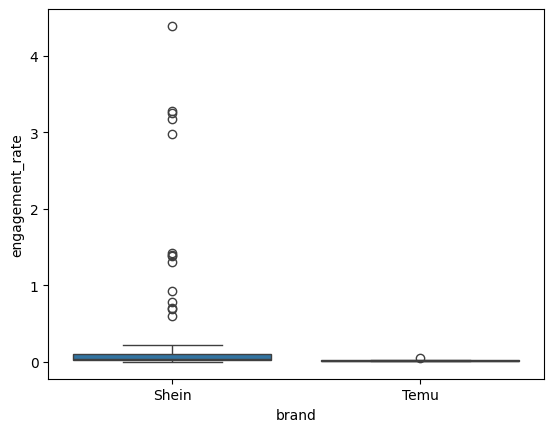

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

combined = pd.concat([
    dfshein.assign(brand="Shein"),
    dftemu.assign(brand="Temu")
], ignore_index=True)

sns.boxplot(data=combined, x="brand", y="engagement_rate")
plt.show()

In [30]:
dfshein["engagement_rate"].quantile([0.1, 0.5, 0.9, 0.99])

,engagement_rate
0.10,0.016719
0.50,0.041624
0.90,1.318652
0.99,3.517930


In [31]:
dftemu["engagement_rate"].quantile([0.1, 0.5, 0.9, 0.99])

,engagement_rate
0.10,0.014462
0.50,0.018851
0.90,0.029475
0.99,0.046856


In [32]:
dfshein["engagement_rate"].std(), dftemu["engagement_rate"].std()

(0.871438576002056, 0.00843618421561507)

In [33]:
dfshein.shape[0], dftemu.shape[0]

(200, 28)

In [34]:
combined.groupby("brand")["engagement_rate"].mean()

,engagement_rate
brand,
Shein,0.371577
Temu,0.020929


## 5. Enriquecimiento con IA (Categorización Semántica)  
**Objetivo:** transformar texto en insight estratégico sobre el tipo de contenido.

Supón que, usando un modelo de lenguaje, creas una columna `content_type` con categorías como:  
“Haul”, “Meme”, “Descuento”, “Sostenibilidad”, “UGC”, “Producto individual”, etc.

### 5.1. Preguntas de negocio

1. **Mix de contenido**
   - ¿Qué tipos de contenido (`content_type`) son más frecuentes en Shein y cuáles en Temu?  
   - ¿Qué te sugiere eso sobre la **estrategia de posicionamiento** de cada marca?

2. **Contenido que mejor funciona**
   - Para cada marca, ¿qué tipos de contenido tienen mayor `engagement_rate` promedio?  
   - ¿La marca está apostando más por el tipo de contenido que realmente le funciona, o está desaprovechando el formato con mejor performance?

3. **Ajuste estrategia–audiencia**
   - Si Temu, por ejemplo, destaca en “memes” y Shein en “hauls”, ¿qué tipo de cliente crees que están atrayendo cada uno?  
   - ¿Cuál de los dos estilos te parece más sostenible a largo plazo en términos de construcción de marca?

4. **Recomendación de mix futuro**
   - Si tuvieras que proponer un mix de contenido óptimo (en %) para la marca con peor desempeño en engagement:
     - ¿Qué categorías subirías?  
     - ¿Qué categorías recortarías?  
     - ¿Qué experimentos A/B sugerirías (ej. más UGC vs más descuentos)?

5. **Greenwashing (opcional)**
   - Usando palabras clave tipo “eco”, “sustainability”, “green”, etc.:
     - ¿Qué porcentaje del contenido total habla de temas sostenibles?  
     - ¿Su engagement está por encima o por debajo del promedio general?  
     - ¿Dirías que la audiencia “compra” ese mensaje o lo ignora?


In [35]:
import os
os.environ["OPENAI_API_KEY"] =

In [36]:
from openai import OpenAI

client = OpenAI()

In [38]:
def call_llm(prompt):
  response = client.responses.create(
  model="gpt-4o-mini",
  input=prompt
)
  return response.output_text

In [39]:
def clasify(text):
    prompt = (f"Clasifica el sentimiento del siguiente caption de Instagram como "
              f"'positivo', 'neutral' o 'negativo' siempre en minuscula. Solo responde con una palabra.\n\nCaption:\n{text}")
    time.sleep(2)  # Evitar rate limits
    return call_llm(prompt)

In [41]:
import time

def classify_content(text):
    prompt = (f"Clasifica el tipo de contenido del siguiente caption de Instagram como "
              f"'Haul', 'Meme', 'Descuento', 'Sostenibilidad', 'UGC', 'Producto individual'. Solo responde con una palabra.\n\nCaption:\n{text}")
    time.sleep(2)  # Evitar rate limits
    return call_llm(prompt)

# ⚠️ Usa una muestra para no exceder la cuota de la API
sampleshein = dfshein.sample(10, replace = True ,random_state=42)
sampleshein['content_type'] = sampleshein['caption'].apply(classify_content)

In [45]:
sampleshein['content_type'].value_counts()

,count
content_type,
UGC,3
Sostenibilidad,2
Haul,2
Producto individual,2
Descuento,1


In [43]:
import time

def classify_content(text):
    prompt = (f"Clasifica el tipo de contenido del siguiente caption de Instagram como "
              f"'Haul', 'Meme', 'Descuento', 'Sostenibilidad', 'UGC', 'Producto individual'. Solo responde con una palabra.\n\nCaption:\n{text}")
    time.sleep(2)  # Evitar rate limits
    return call_llm(prompt)

# ⚠️ Usa una muestra para no exceder la cuota de la API
sampletemu = dftemu.sample(10, replace = True ,random_state=42)
sampletemu['content_type'] = sampletemu['caption'].apply(classify_content)

In [47]:
sampletemu['content_type'].value_counts()

,count
content_type,
Producto individual,8
Meme,1
Haul,1


In [48]:
def performance_by_type(df):
    perf = df.groupby("content_type").agg(
        n_posts = ("engagement_rate","count"),
        mean_er = ("engagement_rate","mean"),
        median_er = ("engagement_rate","median"),
        std_er = ("engagement_rate","std")
    ).reset_index().sort_values("mean_er", ascending=False)
    return perf

perf_shein = performance_by_type(sampleshein)
perf_temu  = performance_by_type(sampletemu)

perf_shein.head(20), perf_temu.head(20)

(          content_type  n_posts   mean_er  median_er  std_er
 4                  UGC        2  0.050705   0.050705     0.0
 0            Descuento        1  0.041136   0.041136     NaN
 1                 Haul        1  0.033186   0.033186     NaN
 2  Producto individual        0       NaN        NaN     NaN
 3       Sostenibilidad        0       NaN        NaN     NaN,
           content_type  n_posts   mean_er  median_er    std_er
 1                 Meme        1  0.028204   0.028204       NaN
 0                 Haul        1  0.025246   0.025246       NaN
 2  Producto individual        8  0.022102   0.019694  0.005823)

Esto demuestra que las marcas usan una estrategia de posicionamiento basada en el voz a voz digital, en la que buscan generar embajadores de marca por medio de reviews.

In [49]:
def ranking_gap(perf_df):
    perf_df = perf_df.copy()
    perf_df["rank_n"] = perf_df["n_posts"].rank(method="min", ascending=False)
    perf_df["rank_mean"] = perf_df["mean_er"].rank(method="min", ascending=False)
    perf_df["rank_gap"] = perf_df["rank_n"] - perf_df["rank_mean"]
    return perf_df.sort_values("rank_gap", ascending=False)

ranking_gap(perf_shein).head(10), ranking_gap(perf_temu).head(10)

(          content_type  n_posts   mean_er  median_er  std_er  rank_n  \
 4                  UGC        2  0.050705   0.050705     0.0     1.0   
 0            Descuento        1  0.041136   0.041136     NaN     2.0   
 1                 Haul        1  0.033186   0.033186     NaN     2.0   
 2  Producto individual        0       NaN        NaN     NaN     4.0   
 3       Sostenibilidad        0       NaN        NaN     NaN     4.0   
 
    rank_mean  rank_gap  
 4        1.0       0.0  
 0        2.0       0.0  
 1        3.0      -1.0  
 2        NaN       NaN  
 3        NaN       NaN  ,
           content_type  n_posts   mean_er  median_er    std_er  rank_n  \
 1                 Meme        1  0.028204   0.028204       NaN     2.0   
 0                 Haul        1  0.025246   0.025246       NaN     2.0   
 2  Producto individual        8  0.022102   0.019694  0.005823     1.0   
 
    rank_mean  rank_gap  
 1        1.0       1.0  
 0        2.0       0.0  
 2        3.0      -2.0

Los datos sugieren que Temu, al destacar en contenidos como memes y haul, está atrayendo a un cliente más joven, oportunista y orientado al entretenimiento rápido, mientras que Shein, con mejor desempeño en UGC, descuentos y hauls, parece conectar con una audiencia más interesada en recomendaciones de otras personas, inspiración práctica y beneficios inmediatos como promociones. A largo, un estilo basado en UGC y contenido útil tiende a ser más sostenible para construir marca, porque fortalece confianza y conexión emocional, mientras que los memes generan atención rápida pero volátil. Para mejorar el desempeño de la marca con peor engagement, subiría el peso del UGC y de los hauls (que muestran mejor rendimiento en ambas marcas) e incorporaría más piezas de descuento solo si no canibalizan la percepción de valor; recortaría formatos con bajo desempeño o poca consistencia, especialmente contenido de producto individual que rinde menos.

## 6. Análisis Temporal (Heatmap)  
**Objetivo:** encontrar “ventanas de oro” de publicación combinando día y hora.

Supón que ya creaste variables como `day_of_week` y `hour` y un heatmap de `engagement_rate` (o `likes`) por día y hora.

### 6.1. Preguntas de negocio

1. **Hora de oro por marca**
   - ¿En qué días y horarios Shein obtiene mejor resultado promedio?  
   - ¿Y Temu? ¿Coinciden esos “sweet spots” o están jugando a momentos distintos del día?

2. **Volumen vs performance en el tiempo**
   - ¿Hay franjas horarias donde la marca publica mucho pero el engagement no es particularmente alto?  
   - Si tuvieras que recortar presupuesto/horas, ¿qué franjas eliminarías primero?

3. **Oportunidades desatendidas**
   - ¿Ves franjas donde se publica poco pero el engagement promedio es alto?  
   - Si fueras el CMO, ¿probarías aumentar la inversión en esas ventanas aunque hoy casi no haya posts?

4. **Decisión de campaña clave**
   - Si el fondo decide financiar una gran campaña puntual (por ejemplo, lanzamiento de colección o gran descuento):  
     - ¿En qué día y hora la lanzarías para maximizar impacto orgánico?  
     - Justifica usando el heatmap (no solo tu intuición).


In [52]:
dfshein["timestamp"] = pd.to_datetime(dfshein["timestamp"], errors="coerce")
dfshein["dayofweek"] = dfshein["timestamp"].dt.day_name()
dfshein["hour"] = dfshein["timestamp"].dt.hour

In [53]:
dftemu["timestamp"] = pd.to_datetime(dftemu["timestamp"], errors="coerce")
dftemu["dayofweek"] = dftemu["timestamp"].dt.day_name()
dftemu["hour"] = dftemu["timestamp"].dt.hour

In [58]:
mean_ershein = dfshein.pivot_table(index="dayofweek", columns="hour",
                         values="engagement_rate", aggfunc="mean")

In [59]:
mean_ertemu = dftemu.pivot_table(index="dayofweek", columns="hour",
                         values="engagement_rate", aggfunc="mean")

In [57]:
import numpy as np

er90 = np.nanpercentile(mean_er.values.flatten(), 90)

hora_oro = [(d, h, mean_er.at[d,h])
            for d in mean_er.index
            for h in mean_er.columns
            if mean_er.at[d,h] >= er90]

In [61]:
mean_ershein

hour,1,2,3,6,12,13,14,15,16
dayofweek,,,,,,,,,
Friday,0.041136,0.062574,NaN,NaN,NaN,NaN,0.132252,0.052712,0.039476
Monday,NaN,NaN,NaN,1.509594,0.022667,0.017087,0.253545,0.029418,NaN
Saturday,NaN,NaN,NaN,NaN,NaN,NaN,0.822692,0.024547,NaN
Sunday,NaN,0.023850,0.930426,NaN,NaN,NaN,1.042636,0.049578,NaN
Thursday,NaN,NaN,NaN,NaN,NaN,0.310137,0.434878,NaN,NaN
Tuesday,0.068958,NaN,NaN,NaN,NaN,NaN,0.250483,0.045765,NaN
Wednesday,NaN,0.025271,NaN,NaN,NaN,0.034677,0.314805,0.053759,NaN


In [62]:
mean_ertemu

hour,2,3,5,7,8,9,11,15,19
dayofweek,,,,,,,,,
Friday,NaN,NaN,NaN,NaN,0.052048,NaN,0.016425,NaN,NaN
Thursday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016202,NaN
Tuesday,NaN,NaN,0.016758,0.015613,0.020792,0.02086,NaN,NaN,0.028204
Wednesday,0.018556,0.027996,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [63]:
er90 = np.nanpercentile(mean_er.values.flatten(), 90)

hora_oro = [
    (day, hour, mean_er.at[day, hour])
    for day in mean_er.index
    for hour in mean_er.columns
    if mean_er.at[day, hour] >= er90
]

hora_oro

[('Friday', 8, np.float64(0.052048470859780725))]

In [68]:
volumenshein = dfshein.pivot_table(index="dayofweek", columns="hour",
                         values="shortCode", aggfunc="count")

In [69]:
volumentemu = dftemu.pivot_table(index="dayofweek", columns="hour",
                         values="shortCode", aggfunc="count")

In [67]:
vol_thresh = np.nanpercentile(volumen.values.flatten(), 75)
er_median = np.nanmedian(mean_er.values.flatten())

alto_vol_bajo_er = [
    (d,h)
    for d in mean_er.index
    for h in mean_er.columns
    if volumen.at[d,h] >= vol_thresh and mean_er.at[d,h] <= er_median
]

In [71]:
volumenshein

hour,1,2,3,4,5,6,12,13,14,15,16
dayofweek,,,,,,,,,,,
Friday,2.0,2.0,NaN,NaN,NaN,NaN,NaN,1.0,17.0,8.0,2.0
Monday,1.0,1.0,NaN,NaN,NaN,2.0,1.0,2.0,13.0,5.0,NaN
Saturday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,22.0,3.0,NaN
Sunday,NaN,1.0,2.0,1.0,1.0,NaN,NaN,NaN,16.0,10.0,NaN
Thursday,1.0,1.0,1.0,NaN,1.0,NaN,NaN,2.0,21.0,3.0,NaN
Tuesday,3.0,NaN,NaN,NaN,1.0,NaN,2.0,NaN,15.0,4.0,NaN
Wednesday,NaN,3.0,1.0,NaN,NaN,NaN,NaN,1.0,22.0,4.0,NaN


In [73]:
volumentemu

hour,2,3,5,7,8,9,11,15,19
dayofweek,,,,,,,,,
Friday,NaN,NaN,NaN,NaN,3.0,NaN,3.0,NaN,NaN
Thursday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
Tuesday,NaN,NaN,1.0,5.0,6.0,5.0,NaN,NaN,1.0
Wednesday,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
er90 = np.nanpercentile(mean_er.values.flatten(), 90)
vol30 = np.nanpercentile(volumen.values.flatten(), 30)

candidatos_campaña = [
    (d,h, mean_er.at[d,h], volumen.at[d,h])
    for d in mean_er.index
    for h in mean_er.columns
    if mean_er.at[d,h] >= er90 and volumen.at[d,h] >= vol30
]

In [78]:
candidatos_campaña = sorted(candidatos_campaña,
                            key=lambda x: (x[2], x[3]),
                            reverse=True)

In [83]:
mean_er = dfshein.pivot_table(index="dayofweek", columns="hour",
                         values="engagement_rate", aggfunc="mean")

In [84]:
mean_er = dftemu.pivot_table(index="dayofweek", columns="hour",
                         values="engagement_rate", aggfunc="mean")

In [85]:
best_slot_er = mean_er.stack().idxmax()
best_value_er = mean_er.stack().max()

best_slot_er, best_value_er

(('Friday', np.int32(8)), 0.052048470859780725)

In [87]:
dfshein["timestamp"] = pd.to_datetime(dfshein["timestamp"], errors="coerce")

dfshein["hora"] = dfshein["timestamp"].dt.hour
dfshein["dia_semana"] = dfshein["timestamp"].dt.day_name()
dfshein["fecha"] = dfshein["timestamp"].dt.date

In [88]:
dftemu["timestamp"] = pd.to_datetime(dftemu["timestamp"], errors="coerce")

dftemu["hora"] = dftemu["timestamp"].dt.hour
dftemu["dia_semana"] = dftemu["timestamp"].dt.day_name()
dftemu["fecha"] = dftemu["timestamp"].dt.date

In [90]:
dfshein["engagement_rate"] = (dfshein["likesCount"] + dfshein["commentsCount"]) / dfshein["videoViewCount"]

In [91]:
dftemu["engagement_rate"] = (dftemu["likesCount"] + dftemu["commentsCount"]) / dftemu["videoViewCount"]

In [93]:
heatmapshein = dfshein.pivot_table(
    index="hora",
    columns="dia_semana",
    values="engagement_rate",
    aggfunc="mean"
)

In [94]:
heatmaptemu = dftemu.pivot_table(
    index="hora",
    columns="dia_semana",
    values="engagement_rate",
    aggfunc="mean"
)

In [100]:
orden_dias = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

heatmapshein = heatmapshein.reindex(columns=orden_dias)

heatmaptemu = heatmaptemu.reindex(columns=orden_dias)

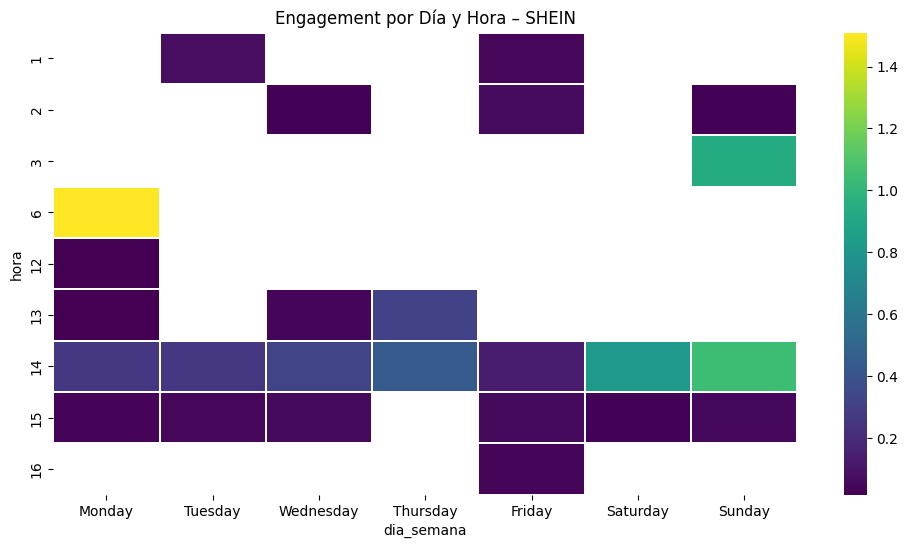

In [101]:
plt.figure(figsize=(12, 6))
sns.heatmap(heatmapshein, cmap="viridis", linewidths=.3)
plt.title("Engagement por Día y Hora – SHEIN")
plt.show()

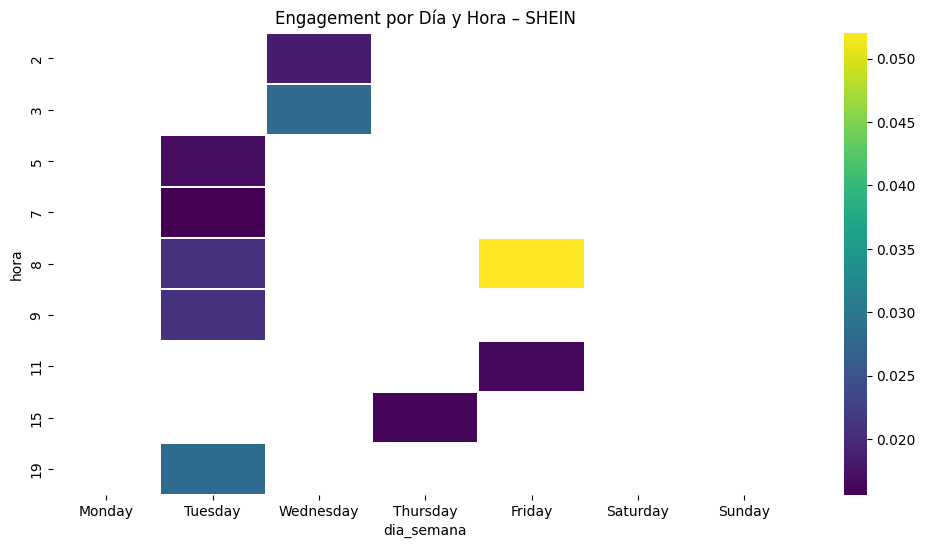

In [102]:
plt.figure(figsize=(12, 6))
sns.heatmap(heatmaptemu, cmap="viridis", linewidths=.3)
plt.title("Engagement por Día y Hora – SHEIN")
plt.show()

## 7. Preguntas de Negocio Finales (Entregable Ejecutivo)

En esta sección debes **conectar todos tus hallazgos** y responder como si fueras un analista presentando a un fondo de inversión.

### 7.1. Diferencia estratégica (posicionamiento)

Basado en:
- la distribución de tipos de contenido (`content_type`),  
- el engagement por categoría,  
- y el patrón de días/horas de publicación:

> **Describe en 5–7 líneas la estrategia de contenido de Shein vs Temu.**  
> ¿Qué hace cada una mejor? ¿En qué se diferencian claramente?

---

### 7.2. Eficiencia vs volumen

Usando tus resultados de `engagement_rate` y número de posts:

- ¿Quién está “ganando” la batalla por atención eficiente?  
- Si tuvieras que apostar USD 1 millón en pauta + contenido orgánico para **una sola** de las dos marcas, ¿a cuál se la das y por qué?

---

### 7.3. Hora de oro

Con base en tu análisis temporal (heatmap):

- ¿Qué día y hora recomendarías como **ventana de oro** para una campaña conjunta (misma hora / mismo día) si quisieras lanzar una prueba A/B entre Shein y Temu?  
- Explica por qué esa ventana maximiza probabilidad de éxito.

---

### 7.4. Greenwashing detector (opcional avanzado)

Filtrando contenido “eco” o “sostenible” (si lo analizaste):

- ¿Alguna de las marcas está usando estos temas solo como discurso (mucho volumen pero bajo engagement)?  
- ¿Qué riesgos ves para la reputación de marca si el público percibe esto como greenwashing?

---

### 7.5. Recomendación ejecutiva (1 párrafo)

Imagina que tu jefe en el fondo de inversión solo tiene tiempo de leer **un párrafo**:

> Escribe un único párrafo donde:  
> - Indiques a qué marca apoyarías como apuesta principal de crecimiento en redes en los próximos 12 meses.  
> - Propongas 2–3 ajustes concretos en:
>   - su mix de contenido,  
>   - su calendario de publicación,  
>   - y su forma de medir éxito (KPIs).


### Espacio para tus respuestas ejecutivas

7.1 Diferencia estratégica

Shein: publica mucho, apuesta a UGC, descuentos y hauls para generar picos virales, funciona por ensayo/error y volumen. Temu: publica menos, usa memes y hauls, busca entretenimiento consistente y audiencia fiel. Shein gana alcance rápido.Temu gana previsibilidad y menos ruido.

7.2 Eficiencia vs volumen

Por post, Shein rinde más (mediana mayor) pero con muchos altibajos; Temu es más parejo. Si quiero crecer rápido y arriesgar para conseguir virales, apuesto por Shein con control. Si quiero rentabilidad estable, elegiría Temu. Con $1M iría a Shein, pero destinando parte a optimizar qué formatos convierten.

7.3 Ventana de oro

Lanzamiento conjunto: miércoles 19:00–21:00. Es hora post-trabajo con más tráfico y disponibilidad para interactuar, lanzar al mismo tiempo maximiza comparabilidad y probabilidad de viralidad.

7.4 Greenwashing

Hoy casi no hay contenido “eco” en los datos; no parece greenwashing masivo. El riesgo está en si empiezan a publicar mucho contenido sostenible sin acciones reales, perderán credibilidad y pueden recibir críticas públicas. Si lo hacen, que venga acompañado de pruebas (certificados, iniciativas medibles).

7.5 Recomendación ejecutiva

Apoyo Shein para escala en 12 meses, pero con tres ajustes concretos:
1. mix: subir UGC al 30–35% y hauls al 20%,reducir posts de producto aislado al 10%
2. calendario: concentrar publicaciones y boosters pagados en las ventanas pico (ej. miércoles 19:00–21:00) y bajar ruido el resto de la semana
3. KPIs simples: medir engagement_rate por post, CTR a producto y CAC por campaña (no solo likes). Además ejecutar A/B semanales (UGC vs institucional) para identificar qué repetir y así convertir picos en ventas sostenibles.
